# Tratamiento de clases no Balanceadas 

Pamela Cerdas 

## Parte 1 

In [3]:
%pip install tabulate


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
pip install tabulate  # instalacion de la lireria tabulate para mostrar tablas en la terminal 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [4]:
# importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score

In [5]:
# Generando los conjuntos desbalanceados:
# n: total de registros a generar
# p0: proporción de registros de la clase mayoritaria (valor 0)
# p1: proporción de registros de la clase minoritaria (valor 1): p1=1-p0
# Obviamente una proporción es complemento del otro, pero especificamos
# ambos para tener presente en todo momento el tipo de desbalanceo que tenemos.

def mis_conjuntos(n, p0, p1):

   X, y = make_classification(
       n_samples=n,             # Se generan "n" registros donde cada factor tiene una distribución gaussiana con varianza 1.
       n_classes=2,             # El conjunto de datos generado constará de dos clases diferentes.
       n_features=2,            # Habrá 2 variables de entrada (factores o variables independientes)
       n_redundant=0,           # No hay factores que sean redundantes, i.e., que uno sea combinación lineal de otros factores.
       n_clusters_per_class=1,  # Cada clase se agrupa alrededor de un único centro.
       weights=[p0, p1],        # [proporción_clase_negativa(0), proporción_clase_positiva(1)]  : p1=1-p0
       flip_y=0.,               # No existen datos mal etiquetados.
       class_sep=0.1,           # Valor que indican la distancia entre clases. Más grande, mayor distancia.
       random_state=0)

   return X,y


# Desplegando la matriz de confusión:
# (etiquetas_reales, etiquetas_de_predicciones)
def mi_cm(yreal, ypred):
  cm = confusion_matrix(yreal, ypred)

  txt = ['Verdaderos Negativos','Falsos Positivos','Falsos Negativos','Verdaderos Positivos']
  vf = [ '( VN )', '( FP )', '( FN )', '( VP )']
  frecuencia = ["{0:0.0f}".format(value) for value in cm.flatten()]
  porcentaje = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

  labels = [f"{v1}\n{v2}\n{v3}\n{v4}" for v1, v2, v3, v4 in zip(txt,vf, frecuencia,porcentaje)]
  labels = np.asarray(labels).reshape(2,2)

  plt.figure(figsize=(6,4))
  ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Pastel1', cbar=False)
  ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")
  plt.show()

Dimensión de datos generados:
Datos de entrada X: (2000, 2)
Variable de salida y: (2000,)


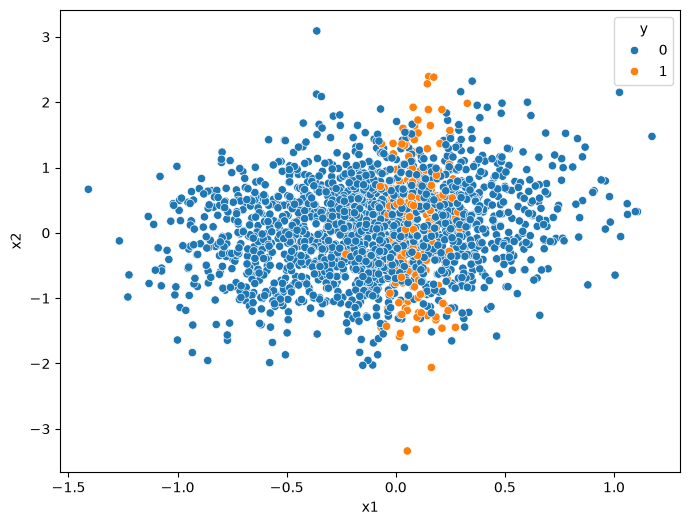

In [6]:
X,y = mis_conjuntos(2000, 0.9, 0.1)

print('Dimensión de datos generados:')
print('Datos de entrada X:', X.shape)
print('Variable de salida y:', y.shape)

# Los transformamos en un DataFrame de Pandas:
df = pd.DataFrame(X, columns=['x1','x2'])
df['y'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='x1', y='x2', hue='y');

In [7]:
# Realicemos una partición considerando solo al conjunto de etrenamiento (70%) y al de validación (30%).
# Esto ya que para los ejemplos que deseamos ilustrar, no requerimos de un conjunto de prueba.

X,y = mis_conjuntos(2000, 0.9, 0.1)

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.70, random_state=1, stratify=y)

In [8]:
# Inicializamos el modelo de regresión logística con los parámetros predeterminados:
modelo = LogisticRegression()

# Entrenamos con los datos de entrenamiento:
modelo.fit(X_train, y_train)

# Realizamos las predicciones con los datos de validación:
yhat = modelo.predict(X_val)

# Veamos el desempeño en cuanto exactitud (accuracy) del modelo:
print('Exactitud del modelo con los datos de prueba: %.1f%%' % (100*modelo.score(X_val,y_val)))

Exactitud del modelo con los datos de prueba: 90.0%


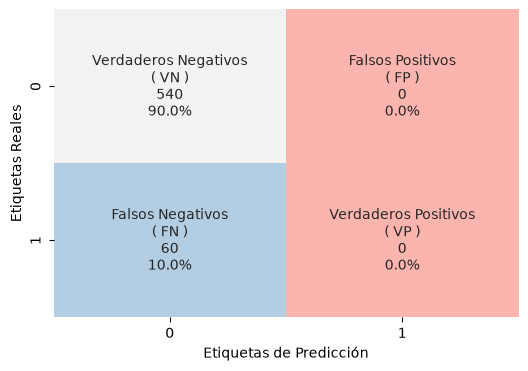

In [9]:
mi_cm(y_val, yhat)

Como se puede observar el modelo mejoro sin ncesidad de muchas transformaciones, obteniendo como resultado un 90% de la veracidad de las predicciones y solo 10% de no.

## Modelo Dummy : Obtencion del punto de partida de las metricas diferentes a la exactitud (accuracy)